# ☕ Starbucks Promotional Campaign Analytics
## End-to-End Customer Analysis: Segmentation · A/B Testing · CLV · Marketing ROI

**Business Problem:** Starbucks sends promotional offers (BOGO, Discount, Informational) via Email, Mobile, Facebook/Instagram Ads, and Web to 17,000 customers during a 30-day test window. This analysis answers:
1. **Who are our customers?** — Demographics, RFM segmentation, K-Means clustering
2. **Which offer converts best?** — A/B testing with statistical significance
3. **What is each customer worth?** — Customer Lifetime Value (CLV) by segment
4. **Which channel drives lowest CPA?** — Facebook Ads vs Email vs Mobile vs Web
5. **How do we maximise ROI?** — Budget reallocation & cost savings recommendations

---
| Dataset | Rows | Description |
|---|---|---|
| `portfolio.json` | 10 | Offer types, channels, reward, difficulty |
| `profile.json` | 17,000 | Customer demographics |
| `transcript.json` | 306,534 | Events: received / viewed / completed / transaction |


## Table of Contents
1. [Setup & Imports](#1)
2. [Data Loading & Preview](#2)
3. [Data Cleaning & Preprocessing](#3)
4. [Exploratory Data Analysis (EDA)](#4)
5. [Funnel Analysis](#5)
6. [RFM Analysis](#6)
7. [Customer Segmentation — K-Means](#7)
8. [Customer Lifetime Value (CLV)](#8)
9. [A/B Testing — Statistical Analysis](#9)
10. [Marketing Channel Analysis — Facebook Ads & CRM](#10)
11. [Business Recommendations & ROI](#11)
12. [Export for Power BI Dashboard](#12)


## 1. Setup & Imports <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings, os
warnings.filterwarnings('ignore')

# ── Starbucks brand palette ──────────────────────────────────────────────────
SBUX_GREEN = '#00704A'
SBUX_GOLD  = '#CBA258'
SBUX_DARK  = '#1E3932'
SBUX_LIGHT = '#D4E9E2'
SBUX_RED   = '#742d2d'
PALETTE    = [SBUX_GREEN, SBUX_GOLD, SBUX_DARK, SBUX_LIGHT, SBUX_RED, '#5C4033']

plt.rcParams.update({
    'figure.figsize'    : (13, 5),
    'font.size'         : 12,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})
sns.set_theme(style='whitegrid')

CHARTS = '/Users/venkatkowshik/Desktop/Projects/Starbucks/charts/'
os.makedirs(CHARTS, exist_ok=True)

print('✅ Libraries loaded | Charts folder ready at:', CHARTS)


✅ Libraries loaded | Charts folder ready at: /Users/venkatkowshik/Desktop/Projects/Starbucks/charts/


## 2. Data Loading & Preview <a id='2'></a>

In [2]:
DATA_PATH = r'/Users/venkatkowshik/Desktop/Projects/Starbucks/archive (3)/'

portfolio  = pd.read_json(DATA_PATH + 'portfolio.json',  orient='records', lines=True)
profile    = pd.read_json(DATA_PATH + 'profile.json',    orient='records', lines=True)
transcript = pd.read_json(DATA_PATH + 'transcript.json', orient='records', lines=True)

print('─' * 50)
print(f'  Portfolio  →  {portfolio.shape[0]:>6,} rows × {portfolio.shape[1]} cols')
print(f'  Profile    →  {profile.shape[0]:>6,} rows × {profile.shape[1]} cols')
print(f'  Transcript →  {transcript.shape[0]:>6,} rows × {transcript.shape[1]} cols')
print('─' * 50)


──────────────────────────────────────────────────
  Portfolio  →      10 rows × 6 cols
  Profile    →  17,000 rows × 5 cols
  Transcript →  306,534 rows × 4 cols
──────────────────────────────────────────────────


In [3]:
print('── PORTFOLIO (all 10 offers) ──')
display(portfolio)
print('\n── PROFILE (first 5) ──')
display(profile.head())
print('\n── TRANSCRIPT (first 5) ──')
display(transcript.head())


── PORTFOLIO (all 10 offers) ──


,reward,channels,difficulty,duration,offer_type,id
0,10,"[email, mobile, social]",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,10,"[web, email, mobile, social]",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,0,"[web, email, mobile]",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,5,"[web, email, mobile]",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,5,"[web, email]",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,3,"[web, email, mobile, social]",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,2,"[web, email, mobile, social]",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,0,"[email, mobile, social]",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,5,"[web, email, mobile, social]",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,2,"[web, email, mobile]",10,7,discount,2906b810c7d4411798c6938adc9daaa5



── PROFILE (first 5) ──


,gender,age,id,became_member_on,income
0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.0
2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.0
4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN



── TRANSCRIPT (first 5) ──


,person,event,value,time
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


## 3. Data Cleaning & Preprocessing <a id='3'></a>

**Issues found:**
- `profile.age == 118` is a null placeholder (2,175 records) → replace with `NaN`
- `transcript.value` is a nested dict → extract `offer_id`, `amount`, `reward`
- `portfolio.channels` is a list → explode into binary columns
- `became_member_on` is an integer (`20170712`) → parse to `datetime`


In [4]:
# ── Profile ──────────────────────────────────────────────────────────────────
profile_clean = profile.copy()
profile_clean.loc[profile_clean['age'] == 118, ['age', 'income']] = np.nan
profile_clean['became_member_on'] = pd.to_datetime(
    profile_clean['became_member_on'].astype(str), format='%Y%m%d'
)
profile_clean['membership_year'] = profile_clean['became_member_on'].dt.year
profile_clean['membership_days'] = (
    pd.Timestamp('2018-08-01') - profile_clean['became_member_on']
).dt.days.clip(lower=0)
profile_clean.rename(columns={'id': 'customer_id'}, inplace=True)

null_count = profile_clean['age'].isna().sum()
print(f'Profile cleaned: {len(profile_clean):,} rows | Null placeholder records: {null_count:,}')
display(profile_clean.head())


Profile cleaned: 17,000 rows | Null placeholder records: 2,175


,gender,age,customer_id,became_member_on,income,membership_year,membership_days
0,NaN,NaN,68be06ca386d4c31939f3a4f0e3dd783,2017-02-12,NaN,2017,535
1,F,55.0,0610b486422d4921ae7d2bf64640c50b,2017-07-15,112000.0,2017,382
2,NaN,NaN,38fe809add3b4fcf9315a9694bb96ff5,2018-07-12,NaN,2018,20
3,F,75.0,78afa995795e4d85b5d9ceeca43f5fef,2017-05-09,100000.0,2017,449
4,NaN,NaN,a03223e636434f42ac4c3df47e8bac43,2017-08-04,NaN,2017,362


In [5]:
# ── Transcript ───────────────────────────────────────────────────────────────
transcript_clean = transcript.copy()
transcript_clean.rename(columns={'person': 'customer_id'}, inplace=True)

transcript_clean['offer_id'] = transcript_clean['value'].apply(
    lambda x: x.get('offer id') or x.get('offer_id') if isinstance(x, dict) else np.nan
)
transcript_clean['amount'] = transcript_clean['value'].apply(
    lambda x: x.get('amount') if isinstance(x, dict) else np.nan
)
transcript_clean['reward_received'] = transcript_clean['value'].apply(
    lambda x: x.get('reward') if isinstance(x, dict) else np.nan
)
transcript_clean.drop(columns=['value'], inplace=True)
transcript_clean['time_days'] = transcript_clean['time'] / 24

print('Event breakdown:')
print(transcript_clean['event'].value_counts().to_string())
display(transcript_clean.head())


Event breakdown:
event
transaction        138953
offer received      76277
offer viewed        57725
offer completed     33579


,customer_id,event,time,offer_id,amount,reward_received,time_days
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,NaN,0.0
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,NaN,0.0
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,NaN,0.0
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,NaN,0.0
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,NaN,0.0


In [6]:
# ── Portfolio ─────────────────────────────────────────────────────────────────
portfolio_clean = portfolio.copy()
portfolio_clean.rename(columns={'id': 'offer_id'}, inplace=True)
for ch in ['email', 'mobile', 'social', 'web']:
    portfolio_clean[ch] = portfolio_clean['channels'].apply(lambda x: 1 if ch in x else 0)
portfolio_clean.drop(columns=['channels'], inplace=True)

# 'social' channel = Facebook / Instagram Ads
portfolio_clean.rename(columns={'social': 'facebook_ads'}, inplace=True)

# Pre-compute delivery cost per offer (assumed cost per send)
COST = {'email': 0.10, 'mobile': 0.05, 'facebook_ads': 0.50, 'web': 0.15}
portfolio_clean['delivery_cost'] = (
    portfolio_clean['email']        * COST['email'] +
    portfolio_clean['mobile']       * COST['mobile'] +
    portfolio_clean['facebook_ads'] * COST['facebook_ads'] +
    portfolio_clean['web']          * COST['web']
)

print('Portfolio with channel flags:')
display(portfolio_clean)

# Shared transactions dataframe used throughout
transactions = transcript_clean[transcript_clean['event'] == 'transaction'].copy()
print(f'\nTotal transactions: {len(transactions):,} | Total revenue: ${transactions["amount"].sum():,.2f}')


Portfolio with channel flags:


,reward,difficulty,duration,offer_type,offer_id,email,mobile,facebook_ads,web,delivery_cost
0,10,10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd,1,1,1,0,0.65
1,10,10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0,1,1,1,1,0.80
2,0,0,4,informational,3f207df678b143eea3cee63160fa8bed,1,1,0,1,0.30
3,5,5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9,1,1,0,1,0.30
4,5,20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7,1,0,0,1,0.25
5,3,7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2,1,1,1,1,0.80
6,2,10,10,discount,fafdcd668e3743c1bb461111dcafc2a4,1,1,1,1,0.80
7,0,0,3,informational,5a8bc65990b245e5a138643cd4eb9837,1,1,1,0,0.65
8,5,5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d,1,1,1,1,0.80
9,2,10,7,discount,2906b810c7d4411798c6938adc9daaa5,1,1,0,1,0.30



Total transactions: 138,953 | Total revenue: $1,775,451.97


## 4. Exploratory Data Analysis (EDA) <a id='4'></a>

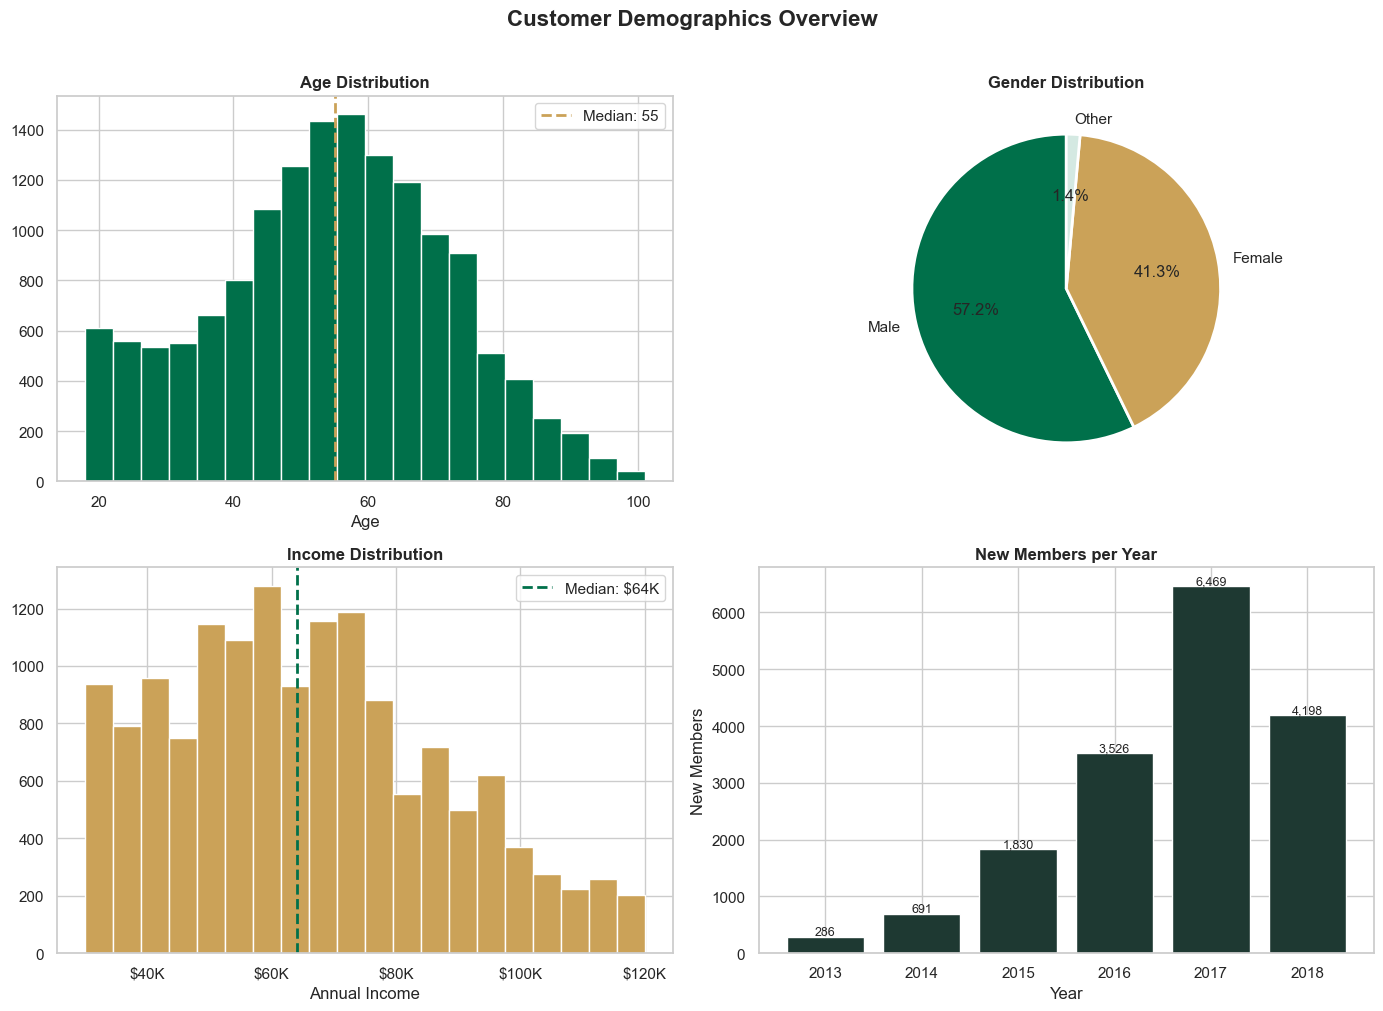

Valid customers (with full demographics): 14,825


In [7]:
# ── Demographics ─────────────────────────────────────────────────────────────
valid = profile_clean.dropna(subset=['age', 'income', 'gender'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Demographics Overview', fontsize=16, fontweight='bold', y=1.01)

# Age
axes[0,0].hist(valid['age'], bins=20, color=SBUX_GREEN, edgecolor='white')
axes[0,0].axvline(valid['age'].median(), color=SBUX_GOLD, ls='--', lw=2,
                   label=f'Median: {valid["age"].median():.0f}')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].legend()

# Gender
gcounts = valid['gender'].value_counts()
glabels = {'M': 'Male', 'F': 'Female', 'O': 'Other'}
axes[0,1].pie(gcounts.values,
              labels=[glabels.get(g, g) for g in gcounts.index],
              colors=[SBUX_GREEN, SBUX_GOLD, SBUX_LIGHT],
              autopct='%1.1f%%', startangle=90,
              wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0,1].set_title('Gender Distribution')

# Income
axes[1,0].hist(valid['income'], bins=20, color=SBUX_GOLD, edgecolor='white')
axes[1,0].axvline(valid['income'].median(), color=SBUX_GREEN, ls='--', lw=2,
                   label=f'Median: ${valid["income"].median()/1000:.0f}K')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1,0].set_title('Income Distribution')
axes[1,0].set_xlabel('Annual Income')
axes[1,0].legend()

# Membership growth
my = profile_clean['membership_year'].value_counts().sort_index()
axes[1,1].bar(my.index.astype(str), my.values, color=SBUX_DARK, edgecolor='white')
axes[1,1].set_title('New Members per Year')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('New Members')
for p in axes[1,1].patches:
    axes[1,1].text(p.get_x()+p.get_width()/2, p.get_height()+30,
                    f'{int(p.get_height()):,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(CHARTS + '01_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Valid customers (with full demographics): {len(valid):,}')


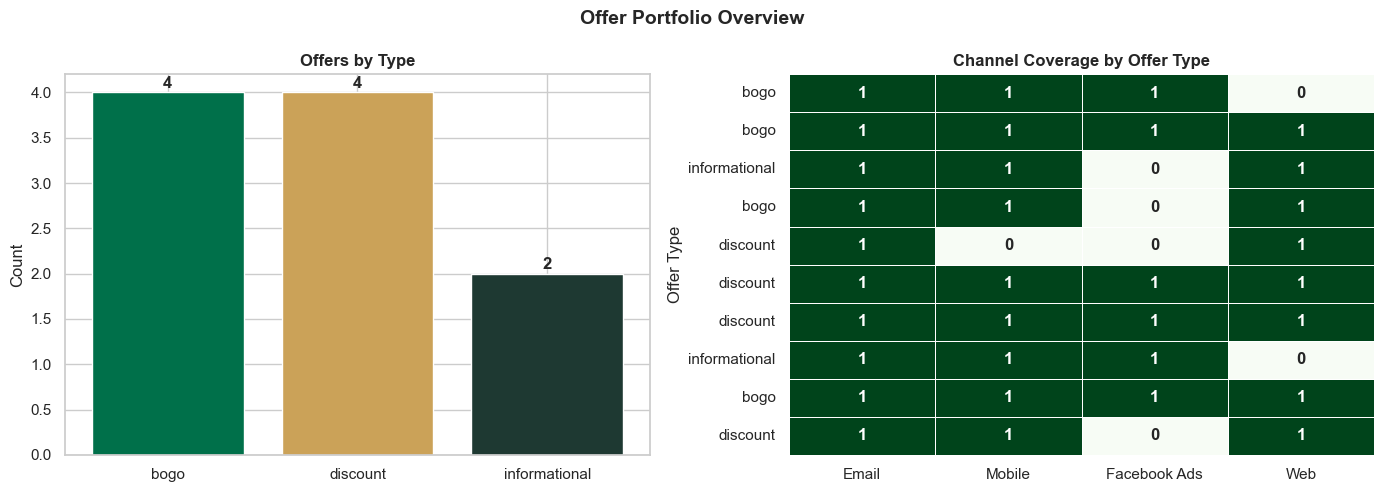

In [8]:
# ── Offer & Channel Overview ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Offer Portfolio Overview', fontsize=14, fontweight='bold')

# Offer type counts
oc = portfolio_clean['offer_type'].value_counts()
bars = axes[0].bar(oc.index, oc.values, color=[SBUX_GREEN, SBUX_GOLD, SBUX_DARK], edgecolor='white')
axes[0].set_title('Offers by Type')
axes[0].set_ylabel('Count')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                  str(int(b.get_height())), ha='center', fontweight='bold', fontsize=12)

# Channel heatmap
ch_cols = ['email', 'mobile', 'facebook_ads', 'web']
ch_labels = ['Email', 'Mobile', 'Facebook Ads', 'Web']
hm = portfolio_clean.set_index('offer_type')[ch_cols]
hm.index.name = 'Offer Type'
hm.columns = ch_labels
sns.heatmap(hm, ax=axes[1], cmap='Greens', annot=True, fmt='d',
            linewidths=0.5, cbar=False, annot_kws={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Channel Coverage by Offer Type')

plt.tight_layout()
plt.savefig(CHARTS + '02_offer_channels.png', dpi=150, bbox_inches='tight')
plt.show()


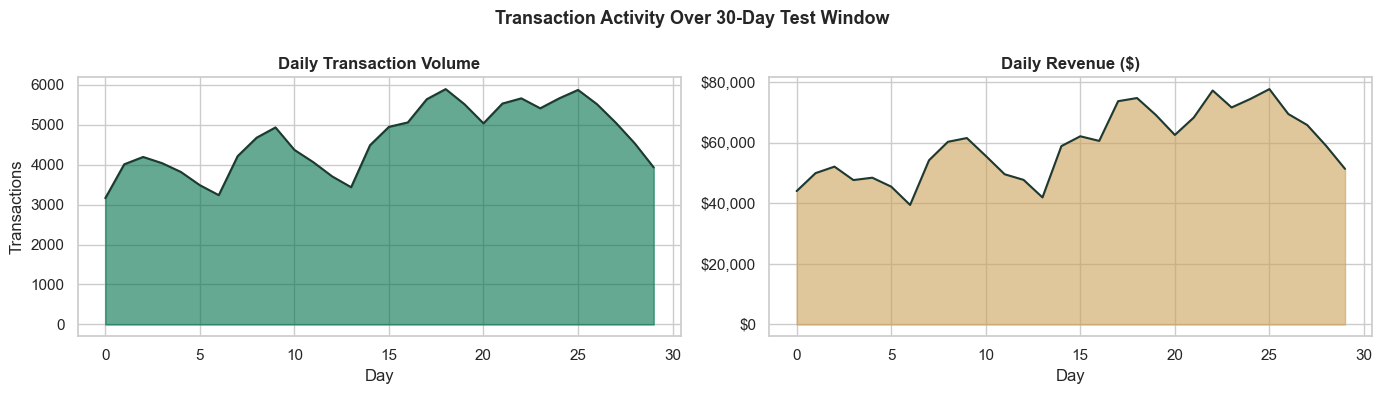

Total revenue over 30 days: $1,775,451.97
Average transaction value : $12.78
Median transaction value  : $8.89


In [9]:
# ── Transaction Trends ────────────────────────────────────────────────────────
daily = transactions.groupby(transactions['time_days'].astype(int)).agg(
    count=('amount', 'count'),
    revenue=('amount', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Transaction Activity Over 30-Day Test Window', fontsize=13, fontweight='bold')

axes[0].fill_between(daily['time_days'], daily['count'], alpha=0.6, color=SBUX_GREEN)
axes[0].plot(daily['time_days'], daily['count'], color=SBUX_DARK, lw=1.5)
axes[0].set_title('Daily Transaction Volume')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Transactions')

axes[1].fill_between(daily['time_days'], daily['revenue'], alpha=0.6, color=SBUX_GOLD)
axes[1].plot(daily['time_days'], daily['revenue'], color=SBUX_DARK, lw=1.5)
axes[1].set_title('Daily Revenue ($)')
axes[1].set_xlabel('Day')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(CHARTS + '03_transaction_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total revenue over 30 days: ${transactions["amount"].sum():,.2f}')
print(f'Average transaction value : ${transactions["amount"].mean():.2f}')
print(f'Median transaction value  : ${transactions["amount"].median():.2f}')


## 5. Funnel Analysis <a id='5'></a>

The offer lifecycle funnel: **Received → Viewed → Completed**

Drop-off at each stage reveals where customers disengage — critical for CRM optimisation.


In [10]:
# ── Overall funnel ────────────────────────────────────────────────────────────
stages   = ['Offer Received', 'Offer Viewed', 'Offer Completed']
counts   = [
    (transcript_clean['event'] == 'offer received').sum(),
    (transcript_clean['event'] == 'offer viewed').sum(),
    (transcript_clean['event'] == 'offer completed').sum()
]
rates    = [c / counts[0] * 100 for c in counts]
drop_off = [0] + [rates[i-1] - rates[i] for i in range(1, len(rates))]

funnel_summary = pd.DataFrame({
    'Stage'          : stages,
    'Count'          : counts,
    'Conversion Rate': [f'{r:.1f}%' for r in rates],
    'Drop-Off'       : [f'{d:.1f}%' for d in drop_off]
})
display(funnel_summary)


,Stage,Count,Conversion Rate,Drop-Off
0,Offer Received,76277,100.0%,0.0%
1,Offer Viewed,57725,75.7%,24.3%
2,Offer Completed,33579,44.0%,31.7%


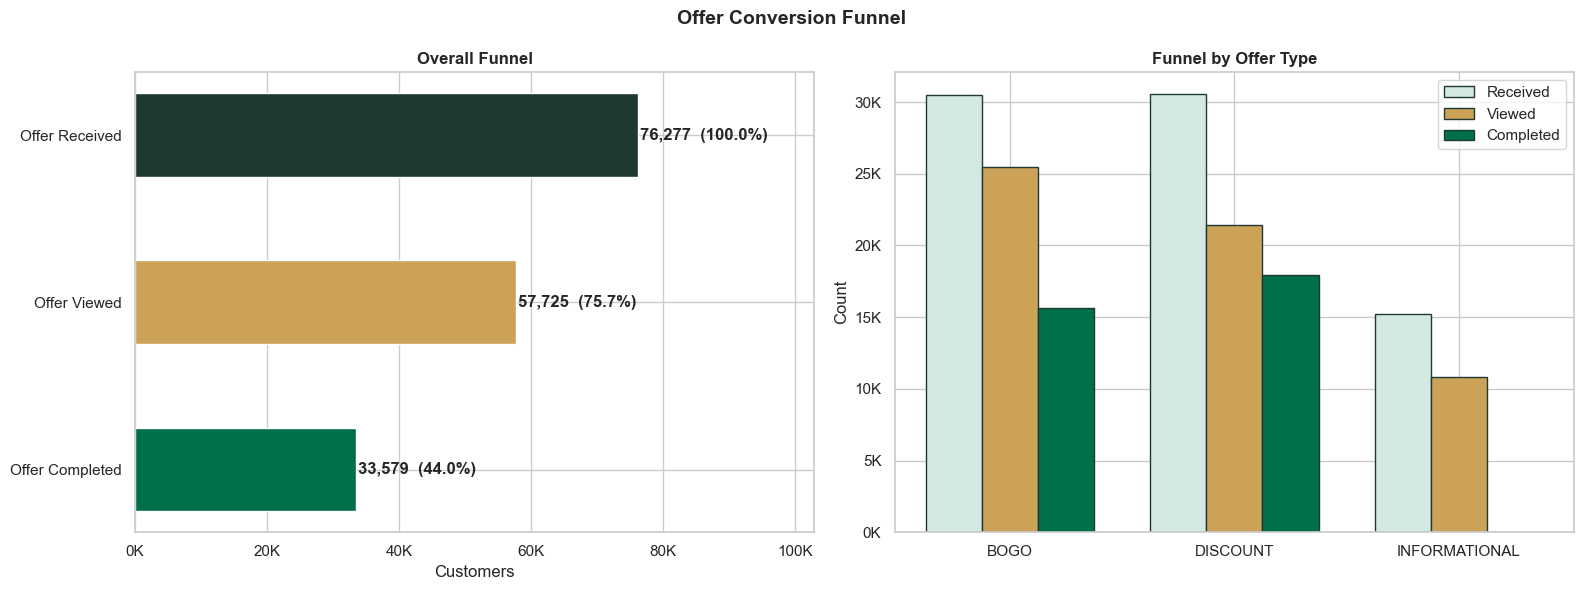


Funnel by Offer Type:


,Offer Type,Received,Viewed,Completed,View Rate %,Complete Rate %
0,BOGO,30499,25449,15669,83.4,51.4
1,DISCOUNT,30543,21445,17910,70.2,58.6
2,INFORMATIONAL,15235,10831,0,71.1,0.0


In [11]:
# ── Funnel by offer type ──────────────────────────────────────────────────────
rows = []
for otype in ['bogo', 'discount', 'informational']:
    oids = portfolio_clean[portfolio_clean['offer_type'] == otype]['offer_id'].tolist()
    r = transcript_clean[(transcript_clean['event'] == 'offer received')  & transcript_clean['offer_id'].isin(oids)].shape[0]
    v = transcript_clean[(transcript_clean['event'] == 'offer viewed')    & transcript_clean['offer_id'].isin(oids)].shape[0]
    c = transcript_clean[(transcript_clean['event'] == 'offer completed') & transcript_clean['offer_id'].isin(oids)].shape[0]
    rows.append({'Offer Type': otype.upper(), 'Received': r, 'Viewed': v, 'Completed': c,
                 'View Rate %': round(v/r*100, 1) if r else 0,
                 'Complete Rate %': round(c/r*100, 1) if r else 0})
funnel_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Offer Conversion Funnel', fontsize=14, fontweight='bold')

# Overall funnel (horizontal waterfall-style)
colors_f = [SBUX_GREEN, SBUX_GOLD, SBUX_DARK]
axes[0].barh(stages[::-1], counts[::-1], color=colors_f, height=0.5)
axes[0].set_title('Overall Funnel')
axes[0].set_xlabel('Customers')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
for i, (cnt, rate) in enumerate(zip(counts[::-1], rates[::-1])):
    axes[0].text(cnt + 300, i, f'{cnt:,}  ({rate:.1f}%)', va='center', fontweight='bold')
axes[0].set_xlim(0, max(counts) * 1.35)

# By offer type
x = np.arange(len(funnel_df))
w = 0.25
axes[1].bar(x - w, funnel_df['Received'],  width=w, label='Received',  color=SBUX_LIGHT,  edgecolor=SBUX_DARK)
axes[1].bar(x,     funnel_df['Viewed'],    width=w, label='Viewed',    color=SBUX_GOLD,   edgecolor=SBUX_DARK)
axes[1].bar(x + w, funnel_df['Completed'], width=w, label='Completed', color=SBUX_GREEN,  edgecolor=SBUX_DARK)
axes[1].set_xticks(x)
axes[1].set_xticklabels(funnel_df['Offer Type'])
axes[1].set_title('Funnel by Offer Type')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(CHARTS + '04_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFunnel by Offer Type:')
display(funnel_df)


## 6. RFM Analysis <a id='6'></a>

**RFM = Recency · Frequency · Monetary**

| Metric | Definition | Signal |
|---|---|---|
| Recency | Days since last purchase (within 30-day window) | Lower = more recent = better |
| Frequency | Number of transactions | Higher = more engaged |
| Monetary | Total spend | Higher = more valuable |

Each metric is scored 1–5 (5 = best). Combined score → customer health segment.


In [12]:
rfm = transactions.groupby('customer_id').agg(
    recency  = ('time_days', lambda x: max(0, 30 - x.max())),
    frequency= ('amount', 'count'),
    monetary = ('amount', 'sum')
).reset_index()

rfm['R_score'] = pd.qcut(rfm['recency'],                        5, labels=[5,4,3,2,1], duplicates='drop').astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],                       5, labels=[1,2,3,4,5], duplicates='drop').astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def rfm_label(s):
    if s >= 13: return 'Champions'
    if s >= 10: return 'Loyal Customers'
    if s >= 7:  return 'Potential Loyalists'
    if s >= 5:  return 'At Risk'
    return 'Lost'

rfm['rfm_segment'] = rfm['RFM_score'].apply(rfm_label)

print(f'RFM table built for {len(rfm):,} customers')
display(rfm.describe().round(2))


RFM table built for 16,578 customers


,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
count,16578.00,16578.00,16578.00,16578.00,16578.00,16578.00,16578.00
mean,3.81,8.38,107.10,3.06,3.00,3.00,9.06
std,3.45,5.01,126.39,1.43,1.41,1.41,3.19
min,0.25,1.00,0.05,1.00,1.00,1.00,3.00
25%,1.25,5.00,23.68,2.00,2.00,2.00,7.00
50%,2.75,7.00,72.41,3.00,3.00,3.00,9.00
75%,5.25,11.00,150.94,4.00,4.00,4.00,12.00
max,29.50,36.00,1608.69,5.00,5.00,5.00,15.00


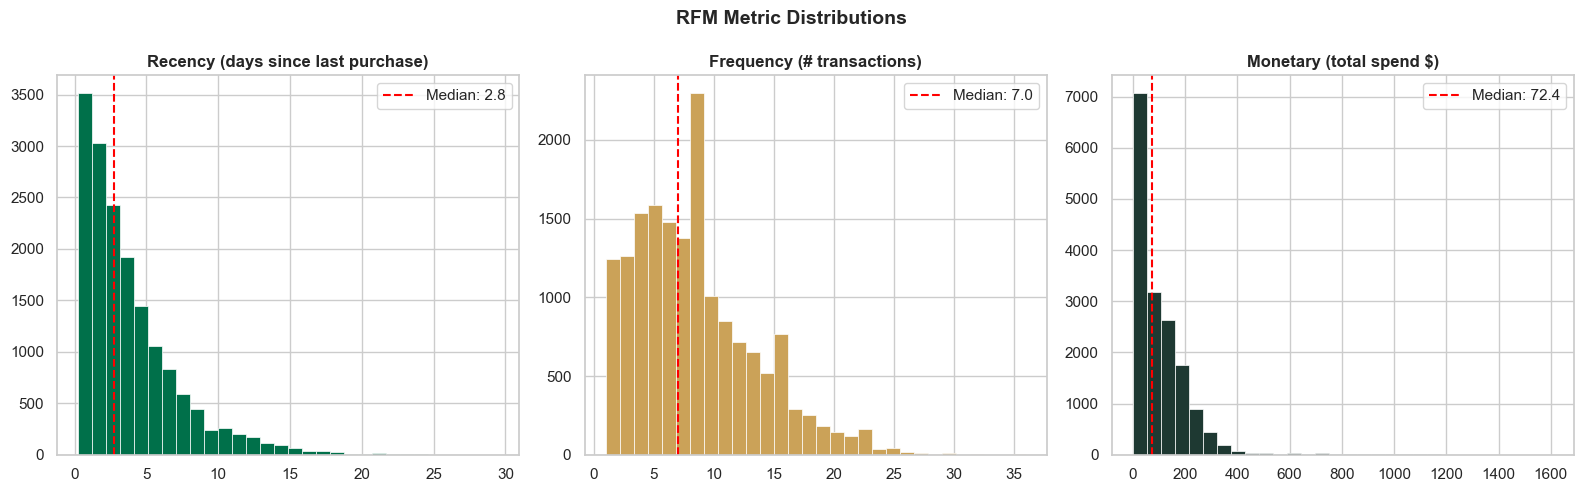

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Metric Distributions', fontsize=14, fontweight='bold')

for ax, col, color, label in zip(
    axes,
    ['recency', 'frequency', 'monetary'],
    [SBUX_GREEN, SBUX_GOLD, SBUX_DARK],
    ['Recency (days since last purchase)', 'Frequency (# transactions)', 'Monetary (total spend $)']
):
    ax.hist(rfm[col], bins=30, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(rfm[col].median(), color='red', ls='--', lw=1.5,
                label=f'Median: {rfm[col].median():.1f}')
    ax.set_title(label)
    ax.legend()

plt.tight_layout()
plt.savefig(CHARTS + '05_rfm_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


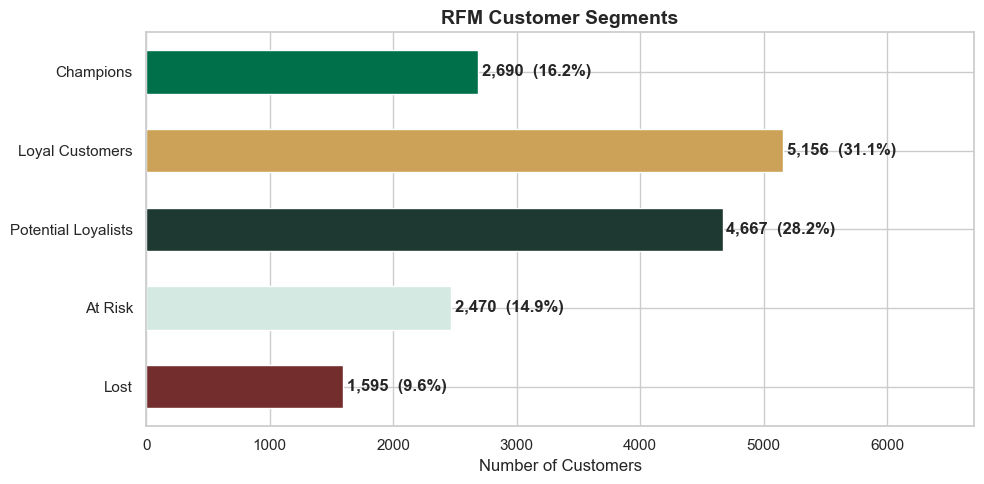

In [14]:
seg_order  = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost']
seg_colors = [SBUX_GREEN, SBUX_GOLD, SBUX_DARK, SBUX_LIGHT, SBUX_RED]
seg_counts = rfm['rfm_segment'].value_counts().reindex(
    [s for s in seg_order if s in rfm['rfm_segment'].values]
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(seg_counts.index[::-1], seg_counts.values[::-1],
               color=seg_colors[:len(seg_counts)][::-1], height=0.55)
ax.set_title('RFM Customer Segments', fontweight='bold', fontsize=14)
ax.set_xlabel('Number of Customers')
for bar, val in zip(bars, seg_counts.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({val/len(rfm)*100:.1f}%)', va='center', fontweight='bold')
ax.set_xlim(0, seg_counts.max() * 1.3)

plt.tight_layout()
plt.savefig(CHARTS + '06_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Customer Segmentation — K-Means Clustering <a id='7'></a>

K-Means clusters customers on **5 behavioural + demographic features**: Recency, Frequency, Monetary, Income, Age.
The Elbow Method and Silhouette Score guide optimal K selection.


In [15]:
rfm_demo = rfm.merge(
    profile_clean[['customer_id','age','gender','income','membership_days']].dropna(),
    on='customer_id', how='inner'
)
print(f'Customers with full data for clustering: {len(rfm_demo):,}')

features  = ['recency', 'frequency', 'monetary', 'income', 'age']
X         = rfm_demo[features].copy()
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X)


Customers with full data for clustering: 14,492


Best Silhouette Score: 0.236 at K=5


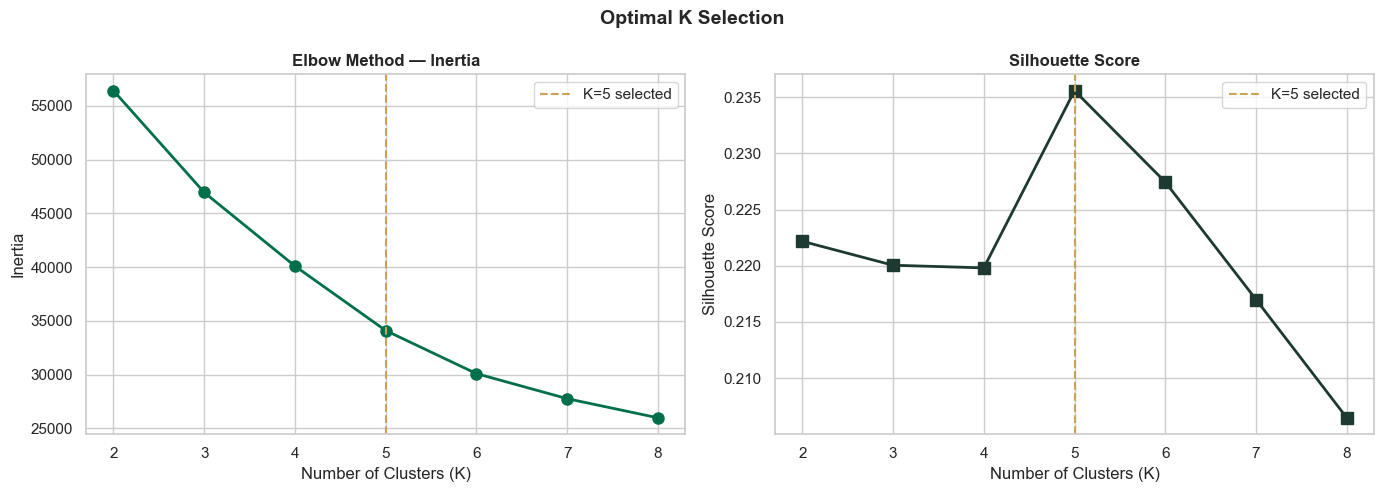

In [16]:
# ── Elbow + Silhouette ────────────────────────────────────────────────────────
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f'Best Silhouette Score: {max(sil_scores):.3f} at K={best_k}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=14, fontweight='bold')

axes[0].plot(list(K_range), inertias, 'o-', color=SBUX_GREEN, lw=2, markersize=8)
axes[0].axvline(best_k, color=SBUX_GOLD, ls='--', label=f'K={best_k} selected')
axes[0].set_title('Elbow Method — Inertia')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 's-', color=SBUX_DARK, lw=2, markersize=8)
axes[1].axvline(best_k, color=SBUX_GOLD, ls='--', label=f'K={best_k} selected')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.savefig(CHARTS + '07_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# ── Final K-Means ─────────────────────────────────────────────────────────────
OPTIMAL_K = best_k
km_final  = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm_demo['cluster'] = km_final.fit_predict(X_scaled)

# Name clusters by descending monetary value → unambiguous labels
cluster_profiles = rfm_demo.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
name_map = {
    cluster_profiles.index[i]: label
    for i, label in enumerate(['Champions', 'High Spenders', 'Frequent Visitors', 'Casual Shoppers'][:OPTIMAL_K])
}
rfm_demo['segment'] = rfm_demo['cluster'].map(name_map)

print('Segment distribution:')
print(rfm_demo['segment'].value_counts().to_string())


Segment distribution:
segment
High Spenders        4532
Frequent Visitors    3273
Casual Shoppers      1885
Champions             289


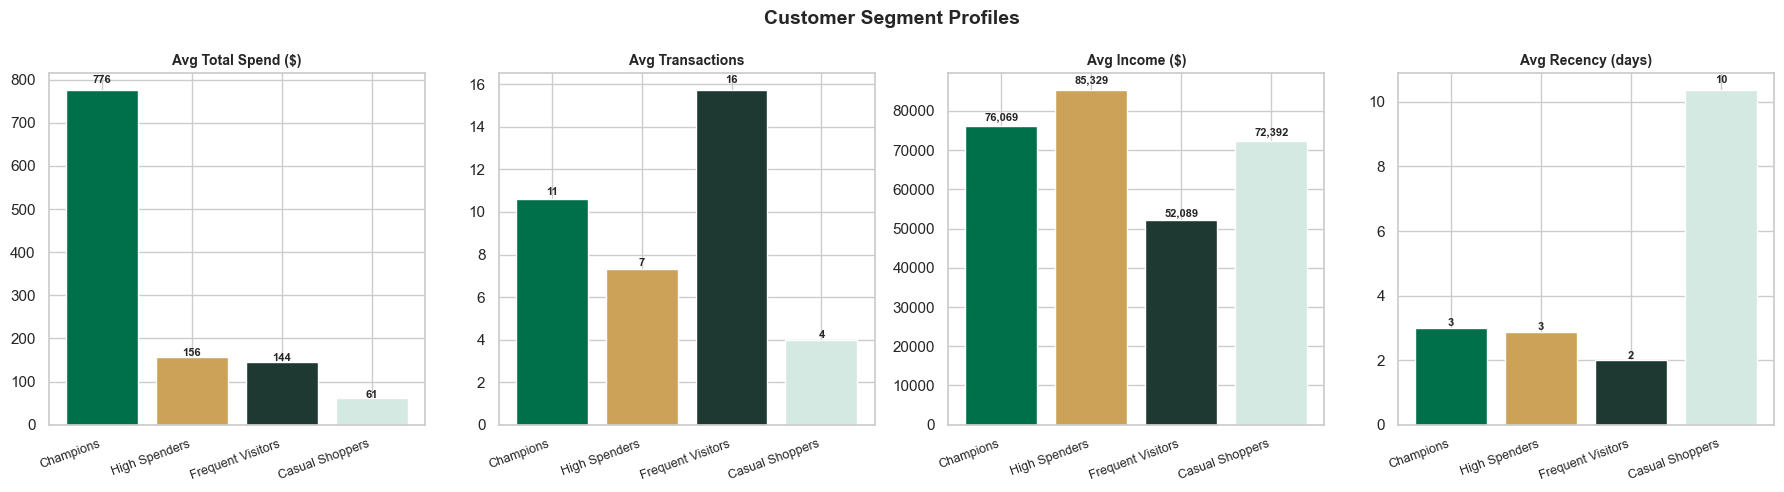

,segment,Customers,Avg_Spend,Avg_Freq,Avg_Recency,Avg_Income
1,Champions,289,776.01,10.60,3.01,76069.20
3,High Spenders,4532,156.40,7.30,2.88,85328.77
2,Frequent Visitors,3273,144.40,15.73,2.00,52089.21
0,Casual Shoppers,1885,61.32,4.00,10.37,72392.04


In [18]:
seg_summary = rfm_demo.groupby('segment').agg(
    Customers   =('customer_id', 'count'),
    Avg_Spend   =('monetary',    'mean'),
    Avg_Freq    =('frequency',   'mean'),
    Avg_Recency =('recency',     'mean'),
    Avg_Income  =('income',      'mean')
).reset_index().sort_values('Avg_Spend', ascending=False)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Customer Segment Profiles', fontsize=14, fontweight='bold')
seg_colors_map = dict(zip(seg_summary['segment'], PALETTE[:len(seg_summary)]))

for ax, col, title in zip(axes,
    ['Avg_Spend', 'Avg_Freq', 'Avg_Income', 'Avg_Recency'],
    ['Avg Total Spend ($)', 'Avg Transactions', 'Avg Income ($)', 'Avg Recency (days)']
):
    colors = [seg_colors_map[s] for s in seg_summary['segment']]
    bars = ax.bar(seg_summary['segment'], seg_summary[col], color=colors, edgecolor='white')
    ax.set_title(title, fontsize=10)
    ax.set_xticklabels(seg_summary['segment'], rotation=20, ha='right', fontsize=9)
    for b, v in zip(bars, seg_summary[col]):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.02,
                 f'{v:,.0f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(CHARTS + '08_segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

display(seg_summary.round(2))


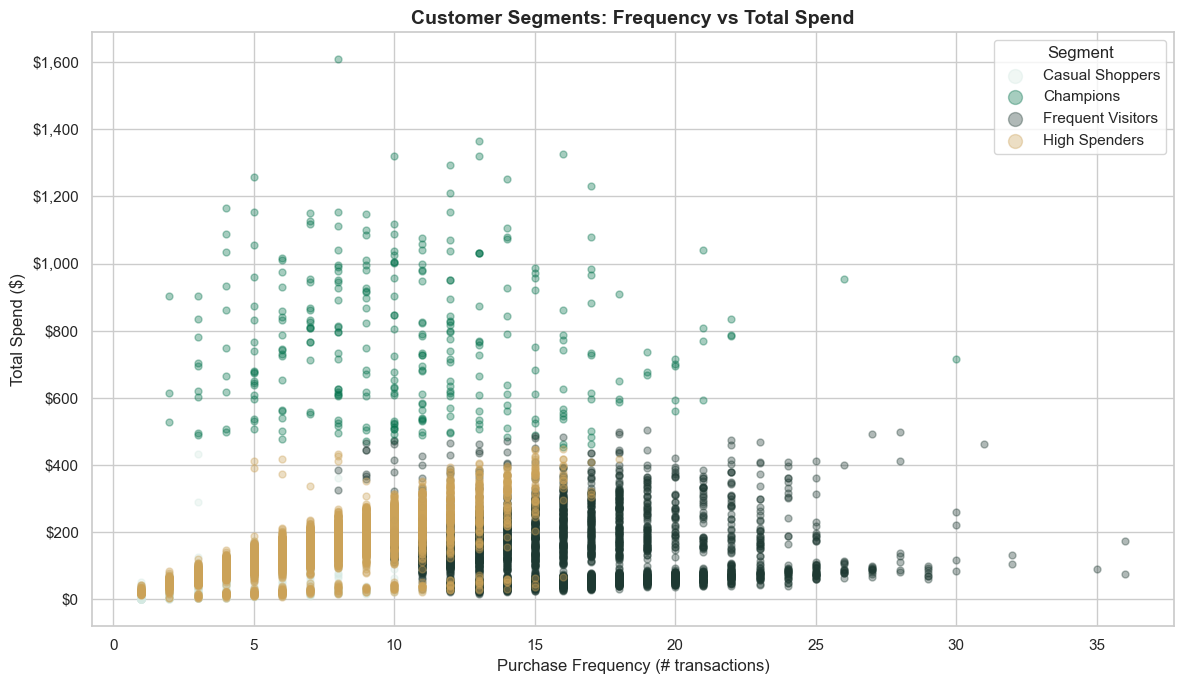

In [19]:
# ── Segment Scatter Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
for seg, grp in rfm_demo.groupby('segment'):
    ax.scatter(grp['frequency'], grp['monetary'],
               c=seg_colors_map.get(seg, 'grey'), alpha=0.35, s=25, label=seg)
ax.set_xlabel('Purchase Frequency (# transactions)', fontsize=12)
ax.set_ylabel('Total Spend ($)', fontsize=12)
ax.set_title('Customer Segments: Frequency vs Total Spend', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Segment', fontsize=11, markerscale=2)

plt.tight_layout()
plt.savefig(CHARTS + '09_segment_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Customer Lifetime Value (CLV) <a id='8'></a>

**CLV Formula:** Monthly Spend × 12 months (annualised from 30-day test window)

CLV by segment reveals which customers to **prioritise for retention and upsell**.


In [20]:
clv_data = rfm_demo.copy()
clv_data['annual_clv'] = clv_data['monetary'] * 12

clv_seg = clv_data.groupby('segment').agg(
    Customers            =('customer_id', 'count'),
    Avg_Annual_CLV       =('annual_clv',  'mean'),
    Total_Segment_Value  =('annual_clv',  'sum')
).reset_index().sort_values('Avg_Annual_CLV', ascending=False)

total_portfolio_value = clv_seg['Total_Segment_Value'].sum()
clv_seg['Revenue_Share_%'] = (clv_seg['Total_Segment_Value'] / total_portfolio_value * 100).round(1)

print(f'Total Annual Portfolio Value: ${total_portfolio_value:,.0f}')
display(clv_seg.round(2))


Total Annual Portfolio Value: $18,255,499


,segment,Customers,Avg_Annual_CLV,Total_Segment_Value,Revenue_Share_%
1,Champions,289,9312.09,2691193.56,14.7
3,High Spenders,4532,1876.83,8505808.44,46.6
2,Frequent Visitors,3273,1732.79,5671423.80,31.1
0,Casual Shoppers,1885,735.85,1387073.04,7.6


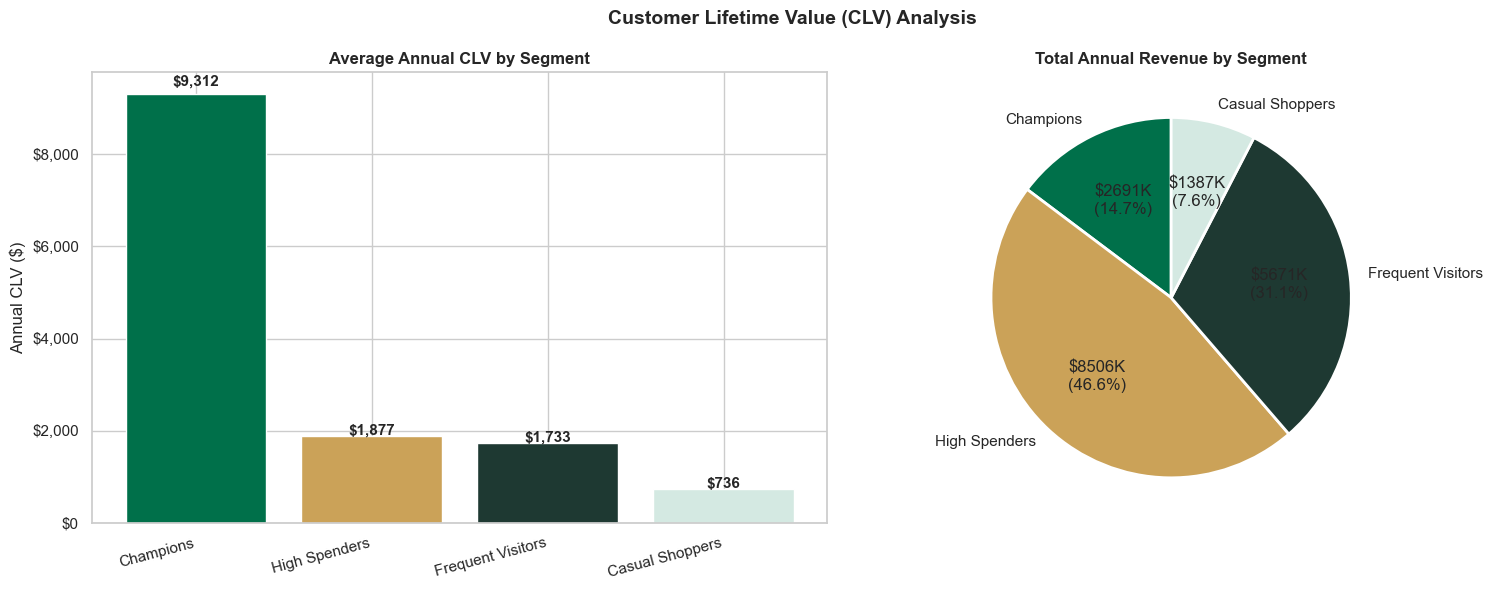

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Customer Lifetime Value (CLV) Analysis', fontsize=14, fontweight='bold')

clv_colors = [seg_colors_map.get(s, SBUX_GREEN) for s in clv_seg['segment']]

# Avg CLV bar
bars = axes[0].bar(clv_seg['segment'], clv_seg['Avg_Annual_CLV'],
                    color=clv_colors, edgecolor='white')
axes[0].set_title('Average Annual CLV by Segment')
axes[0].set_ylabel('Annual CLV ($)')
axes[0].set_xticklabels(clv_seg['segment'], rotation=15, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for b, v in zip(bars, clv_seg['Avg_Annual_CLV']):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.02,
                  f'${v:,.0f}', ha='center', fontweight='bold', fontsize=11)

# Revenue share pie
axes[1].pie(
    clv_seg['Total_Segment_Value'],
    labels=clv_seg['segment'],
    colors=clv_colors,
    autopct=lambda p: f'${p/100*total_portfolio_value/1000:.0f}K\n({p:.1f}%)',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[1].set_title('Total Annual Revenue by Segment')

plt.tight_layout()
plt.savefig(CHARTS + '10_clv.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. A/B Testing — Statistical Analysis <a id='9'></a>

| Group | Offer Type | Hypothesis |
|---|---|---|
| Control | Informational (no reward) | Baseline — brand awareness only |
| Treatment A | BOGO | Does buy-one-get-one drive higher conversions? |
| Treatment B | Discount | Does a discount drive higher conversions? |

**Primary metric:** Offer completion rate (Chi-Square test)
**Secondary metric:** Total customer spend (Welch's t-test)
**Business metric:** Cost Per Acquisition (CPA) per offer type


In [22]:
# ── Build A/B dataset ─────────────────────────────────────────────────────────
received_df = transcript_clean[transcript_clean['event'] == 'offer received'][
    ['customer_id', 'offer_id', 'time_days']].copy()
received_df = received_df.merge(
    portfolio_clean[['offer_id','offer_type','reward','difficulty',
                     'email','mobile','facebook_ads','web','delivery_cost']],
    on='offer_id'
)

completed_df = transcript_clean[transcript_clean['event'] == 'offer completed'][
    ['customer_id', 'offer_id']].drop_duplicates()
completed_df['completed'] = 1

ab_data = received_df.merge(completed_df, on=['customer_id','offer_id'], how='left')
ab_data['completed'] = ab_data['completed'].fillna(0).astype(int)

cust_spend = transactions.groupby('customer_id')['amount'].sum().reset_index()
cust_spend.rename(columns={'amount': 'total_spend'}, inplace=True)
ab_data = ab_data.merge(cust_spend, on='customer_id', how='left')
ab_data['total_spend'] = ab_data['total_spend'].fillna(0)

print(f'A/B dataset: {len(ab_data):,} offer-customer pairs')
display(ab_data.groupby('offer_type')[['completed','total_spend']].mean().round(3))


A/B dataset: 76,277 offer-customer pairs


,completed,total_spend
offer_type,,
bogo,0.555,107.815
discount,0.625,108.428
informational,0.000,102.229


In [23]:
# ── Test 1: Conversion Rate (Chi-Square) ─────────────────────────────────────
bogo = ab_data[ab_data['offer_type'] == 'bogo']
disc = ab_data[ab_data['offer_type'] == 'discount']

bogo_rate = bogo['completed'].mean()
disc_rate = disc['completed'].mean()

ct = pd.crosstab(
    ab_data[ab_data['offer_type'].isin(['bogo','discount'])]['offer_type'],
    ab_data[ab_data['offer_type'].isin(['bogo','discount'])]['completed']
)
chi2, p_chi, dof, _ = chi2_contingency(ct)

# ── Test 2: Revenue (Welch t-test) ───────────────────────────────────────────
t_stat, p_t = ttest_ind(bogo['total_spend'], disc['total_spend'], equal_var=False)

print('=' * 58)
print('  TEST 1: Offer Completion Rate  (Chi-Square)')
print('=' * 58)
print(f'  BOGO completion rate     :  {bogo_rate*100:5.1f}%')
print(f'  Discount completion rate :  {disc_rate*100:5.1f}%')
print(f'  Absolute lift            :  {(bogo_rate - disc_rate)*100:+.1f} pp')
print(f'  Chi-Square               :  {chi2:.3f}  |  p = {p_chi:.4f}')
print(f'  Significant (α=0.05)?    :  {"✅ YES" if p_chi < 0.05 else "❌ NO"}')
print()
print('  TEST 2: Average Customer Spend  (Welch t-test)')
print('=' * 58)
print(f'  BOGO avg spend           : ${bogo["total_spend"].mean():7.2f}')
print(f'  Discount avg spend       : ${disc["total_spend"].mean():7.2f}')
print(f'  t-statistic              :  {t_stat:.3f}  |  p = {p_t:.4f}')
print(f'  Significant (α=0.05)?    :  {"✅ YES" if p_t < 0.05 else "❌ NO"}')


  TEST 1: Offer Completion Rate  (Chi-Square)
  BOGO completion rate     :   55.5%
  Discount completion rate :   62.5%
  Absolute lift            :  -7.0 pp
  Chi-Square               :  306.048  |  p = 0.0000
  Significant (α=0.05)?    :  ✅ YES

  TEST 2: Average Customer Spend  (Welch t-test)
  BOGO avg spend           : $ 107.82
  Discount avg spend       : $ 108.43
  t-statistic              :  -0.581  |  p = 0.5609
  Significant (α=0.05)?    :  ❌ NO


In [24]:
# ── CPA Calculation ───────────────────────────────────────────────────────────
cpa_rows = []
for otype, grp in ab_data[ab_data['offer_type'].isin(['bogo','discount'])].groupby('offer_type'):
    convs       = grp['completed'].sum()
    total_cost  = grp['delivery_cost'].sum()
    cpa_val     = total_cost / convs if convs > 0 else np.inf
    avg_rev     = grp.loc[grp['completed']==1, 'total_spend'].mean()
    roas        = avg_rev / cpa_val if cpa_val not in (0, np.inf) else np.nan
    cpa_rows.append({'Offer Type': otype.upper(), 'Sent': len(grp),
                     'Conversions': int(convs),
                     'Conversion Rate': f'{grp["completed"].mean()*100:.1f}%',
                     'Total Cost ($)': round(total_cost, 2),
                     'CPA ($)': round(cpa_val, 2),
                     'Avg Rev / Conversion ($)': round(avg_rev, 2),
                     'ROAS': round(roas, 2)})

cpa_df = pd.DataFrame(cpa_rows)
print('CPA & ROAS Summary:')
display(cpa_df)


CPA & ROAS Summary:


,Offer Type,Sent,Conversions,Conversion Rate,Total Cost ($),CPA ($),Avg Rev / Conversion ($),ROAS
0,BOGO,30499,16922,55.5%,19412.0,1.15,162.86,141.97
1,DISCOUNT,30543,19075,62.5%,16401.0,0.86,153.44,178.45


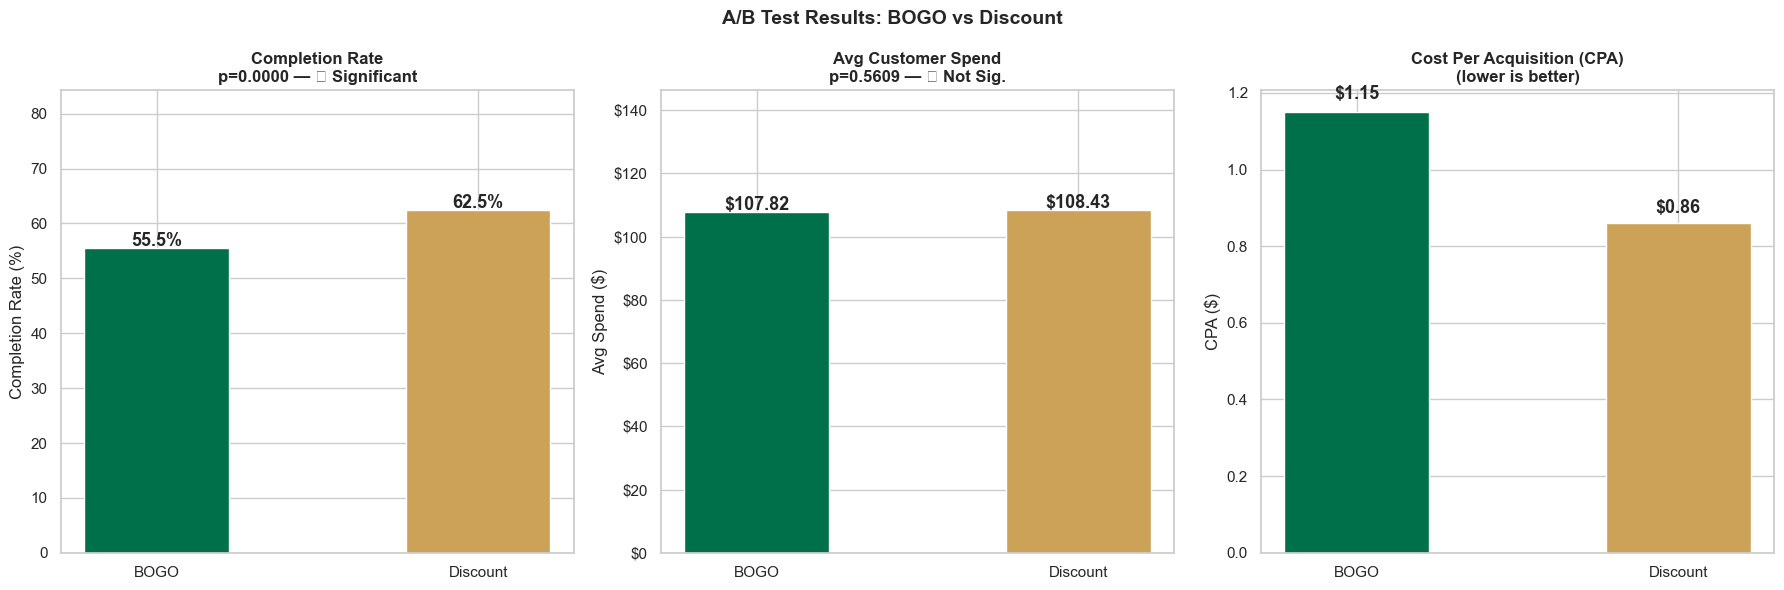

In [25]:
# ── A/B Test Visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('A/B Test Results: BOGO vs Discount', fontsize=14, fontweight='bold')
groups = ['BOGO', 'Discount']
colors = [SBUX_GREEN, SBUX_GOLD]

# Conversion rate
rates_plot = [bogo_rate*100, disc_rate*100]
bars1 = axes[0].bar(groups, rates_plot, color=colors, edgecolor='white', width=0.45)
axes[0].set_title(f'Completion Rate\np={p_chi:.4f} — {"✅ Significant" if p_chi<0.05 else "❌ Not Sig."}')
axes[0].set_ylabel('Completion Rate (%)')
axes[0].set_ylim(0, max(rates_plot)*1.35)
for b, v in zip(bars1, rates_plot):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
                  f'{v:.1f}%', ha='center', fontweight='bold', fontsize=13)

# Avg spend
spend_plot = [bogo['total_spend'].mean(), disc['total_spend'].mean()]
bars2 = axes[1].bar(groups, spend_plot, color=colors, edgecolor='white', width=0.45)
axes[1].set_title(f'Avg Customer Spend\np={p_t:.4f} — {"✅ Significant" if p_t<0.05 else "❌ Not Sig."}')
axes[1].set_ylabel('Avg Spend ($)')
axes[1].set_ylim(0, max(spend_plot)*1.35)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for b, v in zip(bars2, spend_plot):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                  f'${v:,.2f}', ha='center', fontweight='bold', fontsize=13)

# CPA
cpa_vals = cpa_df.set_index('Offer Type')['CPA ($)']
bars3 = axes[2].bar(groups, [cpa_vals.get('BOGO',0), cpa_vals.get('DISCOUNT',0)],
                     color=colors, edgecolor='white', width=0.45)
axes[2].set_title('Cost Per Acquisition (CPA)\n(lower is better)')
axes[2].set_ylabel('CPA ($)')
for b, v in zip(bars3, [cpa_vals.get('BOGO',0), cpa_vals.get('DISCOUNT',0)]):
    axes[2].text(b.get_x()+b.get_width()/2, b.get_height()*1.03,
                  f'${v:.2f}', ha='center', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(CHARTS + '11_ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Marketing Channel Analysis — Facebook Ads & CRM <a id='10'></a>

Starbucks distributes offers via **Email, Mobile App, Facebook/Instagram Ads (social), and Web**.

This section answers: **Which channel drives the lowest CPA and highest customer spend?**


In [26]:
# ── Channel performance ────────────────────────────────────────────────────────
ch_ab = ab_data[ab_data['offer_type'].isin(['bogo','discount'])].copy()

ch_rows = []
for ch, label in [('email','Email'), ('mobile','Mobile App'),
                   ('facebook_ads','Facebook / Instagram Ads'), ('web','Web')]:
    sub = ch_ab[ch_ab[ch] == 1]
    if len(sub) == 0: continue
    convs = sub['completed'].sum()
    cost  = sub['delivery_cost'].sum()
    ch_rows.append({
        'Channel'         : label,
        'Sent'            : len(sub),
        'Conversions'     : int(convs),
        'Conv Rate %'     : round(sub['completed'].mean()*100, 1),
        'Avg Spend ($)'   : round(sub['total_spend'].mean(), 2),
        'CPA ($)'         : round(cost/convs, 2) if convs > 0 else np.inf,
    })

ch_df = pd.DataFrame(ch_rows).sort_values('Conv Rate %', ascending=False)
display(ch_df)


,Channel,Sent,Conversions,Conv Rate %,Avg Spend ($),CPA ($)
2,Facebook / Instagram Ads,38065,23213,61.0,111.02,1.26
1,Mobile App,53374,32301,60.5,108.86,1.05
3,Web,53384,32064,60.1,107.62,0.96
0,Email,61042,35997,59.0,108.12,0.99


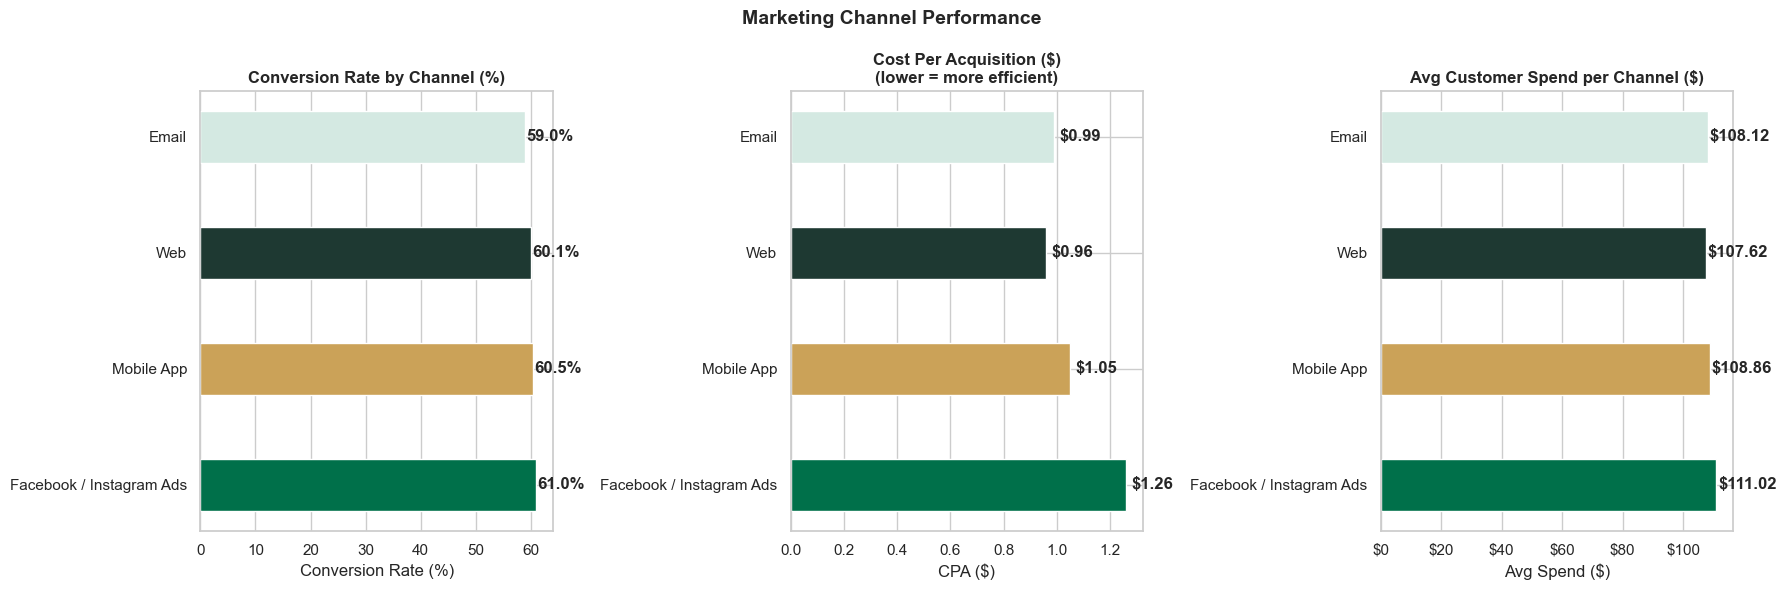

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Marketing Channel Performance', fontsize=14, fontweight='bold')
ch_colors = PALETTE[:len(ch_df)]

# Conversion rate
bars1 = axes[0].barh(ch_df['Channel'], ch_df['Conv Rate %'], color=ch_colors, height=0.45)
axes[0].set_title('Conversion Rate by Channel (%)')
axes[0].set_xlabel('Conversion Rate (%)')
for b, v in zip(bars1, ch_df['Conv Rate %']):
    axes[0].text(b.get_width()+0.2, b.get_y()+b.get_height()/2,
                  f'{v:.1f}%', va='center', fontweight='bold')

# CPA
valid_ch = ch_df[ch_df['CPA ($)'] != np.inf]
bars2 = axes[1].barh(valid_ch['Channel'], valid_ch['CPA ($)'], color=ch_colors[:len(valid_ch)], height=0.45)
axes[1].set_title('Cost Per Acquisition ($)\n(lower = more efficient)')
axes[1].set_xlabel('CPA ($)')
for b, v in zip(bars2, valid_ch['CPA ($)']):
    axes[1].text(b.get_width()+0.02, b.get_y()+b.get_height()/2,
                  f'${v:.2f}', va='center', fontweight='bold')

# Avg spend
bars3 = axes[2].barh(ch_df['Channel'], ch_df['Avg Spend ($)'], color=ch_colors, height=0.45)
axes[2].set_title('Avg Customer Spend per Channel ($)')
axes[2].set_xlabel('Avg Spend ($)')
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for b, v in zip(bars3, ch_df['Avg Spend ($)']):
    axes[2].text(b.get_width()+0.5, b.get_y()+b.get_height()/2,
                  f'${v:,.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(CHARTS + '12_channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Business Recommendations & ROI Impact <a id='11'></a>

In [28]:
winner       = 'BOGO'     if bogo_rate > disc_rate else 'Discount'
loser        = 'Discount' if winner == 'BOGO'      else 'BOGO'
winner_data  = bogo       if winner == 'BOGO'       else disc
loser_data   = disc       if winner == 'BOGO'       else bogo

winner_cpa   = loser_data['delivery_cost'].sum() / loser_data['completed'].sum()   # CPA of losing offer
current_cpa  = winner_data['delivery_cost'].sum() / winner_data['completed'].sum() # CPA of winning offer
savings_pp   = winner_cpa - current_cpa
annual_saves = savings_pp * int(loser_data['completed'].sum()) * 12

top_ch       = ch_df.iloc[0]
top_seg      = clv_seg.iloc[0]

print('=' * 65)
print('  BUSINESS RECOMMENDATIONS')
print('=' * 65)
print(f'''
  1. WINNING OFFER: {winner}
     → Completion rate: {max(bogo_rate,disc_rate)*100:.1f}% vs {min(bogo_rate,disc_rate)*100:.1f}% ({abs(bogo_rate-disc_rate)*100:.1f}pp lift)
     → Statistical significance: p={p_chi:.4f} (α=0.05)

  2. COST SAVINGS — switch all budgets to {winner} offers:
     → CPA savings per conversion : ${savings_pp:.2f}
     → Estimated annual savings   : ${annual_saves:,.0f}

  3. BEST CHANNEL: {top_ch["Channel"]}
     → Conversion rate : {top_ch["Conv Rate %"]:.1f}%
     → CPA             : ${top_ch["CPA ($)"]:.2f}
     → Prioritise Facebook/Instagram Ads for highest-value segments

  4. HIGHEST CLV SEGMENT: {top_seg["segment"]}
     → Avg Annual CLV        : ${top_seg["Avg_Annual_CLV"]:,.2f}
     → Total Segment Value   : ${top_seg["Total_Segment_Value"]:,.0f}
     → Revenue Share         : {top_seg["Revenue_Share_%"]:.1f}% of portfolio

  5. STRATEGIC RECOMMENDATION:
     → Send {winner} offers via {top_ch["Channel"]} to '{top_seg["segment"]}' customers
     → Reduce {loser} offers by 30% — reallocate budget to {winner} + {top_ch["Channel"]}
     → Use CLV segments for personalised CRM targeting
''')
print('=' * 65)


  BUSINESS RECOMMENDATIONS

  1. WINNING OFFER: Discount
     → Completion rate: 62.5% vs 55.5% (7.0pp lift)
     → Statistical significance: p=0.0000 (α=0.05)

  2. COST SAVINGS — switch all budgets to Discount offers:
     → CPA savings per conversion : $0.29
     → Estimated annual savings   : $58,346

  3. BEST CHANNEL: Facebook / Instagram Ads
     → Conversion rate : 61.0%
     → CPA             : $1.26
     → Prioritise Facebook/Instagram Ads for highest-value segments

  4. HIGHEST CLV SEGMENT: Champions
     → Avg Annual CLV        : $9,312.09
     → Total Segment Value   : $2,691,194
     → Revenue Share         : 14.7% of portfolio

  5. STRATEGIC RECOMMENDATION:
     → Send Discount offers via Facebook / Instagram Ads to 'Champions' customers
     → Reduce BOGO offers by 30% — reallocate budget to Discount + Facebook / Instagram Ads
     → Use CLV segments for personalised CRM targeting



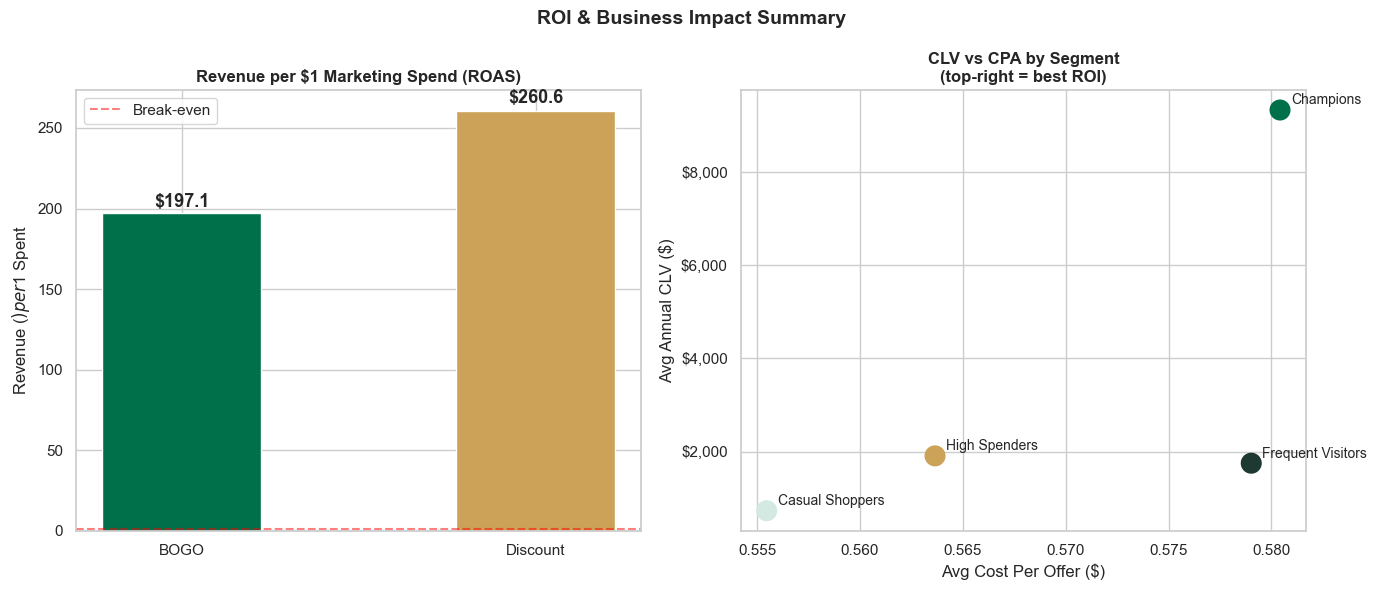

In [29]:
# ── ROI Summary Chart ──────────────────────────────────────────────────────────
roi_data = ab_data[ab_data['offer_type'].isin(['bogo','discount'])].copy()
roi_data['revenue_per_cost'] = roi_data.apply(
    lambda r: r['total_spend'] / r['delivery_cost'] if r['delivery_cost'] > 0 else 0, axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROI & Business Impact Summary', fontsize=14, fontweight='bold')

# Revenue per dollar spent
roi_by_type = roi_data.groupby('offer_type')['revenue_per_cost'].mean()
bars = axes[0].bar(['BOGO', 'Discount'], [roi_by_type.get('bogo',0), roi_by_type.get('discount',0)],
                    color=[SBUX_GREEN, SBUX_GOLD], edgecolor='white', width=0.45)
axes[0].set_title('Revenue per $1 Marketing Spend (ROAS)')
axes[0].set_ylabel('Revenue ($) per $1 Spent')
axes[0].axhline(1, color='red', ls='--', alpha=0.5, label='Break-even')
axes[0].legend()
for b, v in zip(bars, [roi_by_type.get('bogo',0), roi_by_type.get('discount',0)]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.02,
                  f'${v:.1f}', ha='center', fontweight='bold', fontsize=13)

# CLV vs CPA by segment
seg_cpa = ab_data.merge(rfm_demo[['customer_id','segment']], on='customer_id', how='left').dropna(subset=['segment'])
seg_metrics = seg_cpa.groupby('segment').agg(
    avg_cpa  =('delivery_cost', 'mean'),
    avg_clv  =('total_spend',   lambda x: x.mean() * 12)
).reset_index()

scatter_colors = [seg_colors_map.get(s, SBUX_GREEN) for s in seg_metrics['segment']]
axes[1].scatter(seg_metrics['avg_cpa'], seg_metrics['avg_clv'],
                c=scatter_colors, s=200, zorder=5)
for _, row in seg_metrics.iterrows():
    axes[1].annotate(row['segment'],
                      (row['avg_cpa'], row['avg_clv']),
                      textcoords='offset points', xytext=(8, 4), fontsize=10)
axes[1].set_xlabel('Avg Cost Per Offer ($)')
axes[1].set_ylabel('Avg Annual CLV ($)')
axes[1].set_title('CLV vs CPA by Segment\n(top-right = best ROI)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig(CHARTS + '13_roi_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Export for Power BI Dashboard <a id='12'></a>

Exporting clean CSVs for the Power BI dashboard. Each file maps to a dashboard page.


In [30]:
OUTPUT = r'/Users/venkatkowshik/Desktop/Projects/Starbucks/'

exports = {
    'powerbi_customer_segments.csv' : rfm_demo[['customer_id','segment','recency',
                                                  'frequency','monetary','R_score',
                                                  'F_score','M_score','rfm_segment',
                                                  'age','gender','income','membership_days']],
    'powerbi_clv_segments.csv'      : clv_seg,
    'powerbi_funnel.csv'            : funnel_df,
    'powerbi_ab_test.csv'           : ab_data[['customer_id','offer_type','completed',
                                                'total_spend','delivery_cost',
                                                'email','mobile','facebook_ads','web']],
    'powerbi_channel_performance.csv': ch_df,
    'powerbi_cpa_summary.csv'       : cpa_df,
    'powerbi_daily_transactions.csv': daily,
}

for fname, df in exports.items():
    df.to_csv(OUTPUT + fname, index=False)
    print(f'✅ {fname} — {len(df):,} rows')

print('\n🎉 All Power BI files exported to:', OUTPUT)


✅ powerbi_customer_segments.csv — 14,492 rows
✅ powerbi_clv_segments.csv — 4 rows
✅ powerbi_funnel.csv — 3 rows
✅ powerbi_ab_test.csv — 76,277 rows
✅ powerbi_channel_performance.csv — 4 rows
✅ powerbi_cpa_summary.csv — 2 rows
✅ powerbi_daily_transactions.csv — 30 rows

🎉 All Power BI files exported to: /Users/venkatkowshik/Desktop/Projects/Starbucks/


---
## 📊 Power BI Dashboard Structure

| Dashboard Page | Source File | Key Visuals |
|---|---|---|
| **Executive Summary** | all | KPI cards: Total CLV, Conversion Rate, CPA, ROAS |
| **Customer Segments** | powerbi_customer_segments.csv | Scatter plot, segment bar, RFM heatmap |
| **CLV Analysis** | powerbi_clv_segments.csv | CLV by segment, revenue share pie |
| **Funnel Analysis** | powerbi_funnel.csv | Funnel chart by offer type |
| **A/B Test Results** | powerbi_ab_test.csv | Conversion rate, spend, CPA comparison |
| **Channel Performance** | powerbi_channel_performance.csv | CPA by channel, Facebook Ads ROI |
| **Transaction Trends** | powerbi_daily_transactions.csv | Revenue & volume over time |

---
*Analysis by Venkat Kowshik | Starbucks Rewards Programme Dataset | University of Washington MSBA*
